A reliable baseline, because this method works on the principle of **bagging**, so it builds many independent decision trees and averages their predictions. This gave us protection against overfitting again on our array and gave us a clear estimate of the importance of each feature, which is important for the task. And we would like to test the difference between the models, because Random Forest relies on an accurate partition of the data, while XGBoost uses fast histograms and consistently learns from errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('data_for_ML-tgShifted.parquet')
df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]:
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (644060, 227): 2022-03-03 00:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


In [4]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,  
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [5]:
y_prob = model_rf.predict_proba(X_test)[:, 1]

y_pred_03 = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_03, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_03):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1:       {f1_score(y_test, y_pred_03):.4f}")
print(f"MCC:      {matthews_corrcoef(y_test, y_pred_03):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_03):.4f}")

              precision    recall  f1-score   support

    No Alarm       0.95      0.52      0.67    114666
       Alarm       0.44      0.93      0.60     46350

    accuracy                           0.64    161016
   macro avg       0.70      0.73      0.64    161016
weighted avg       0.80      0.64      0.65    161016

Accuracy: 0.6391
ROC-AUC:  0.8696
F1:       0.5981
MCC:      0.4208
Balanced Accuracy: 0.7266


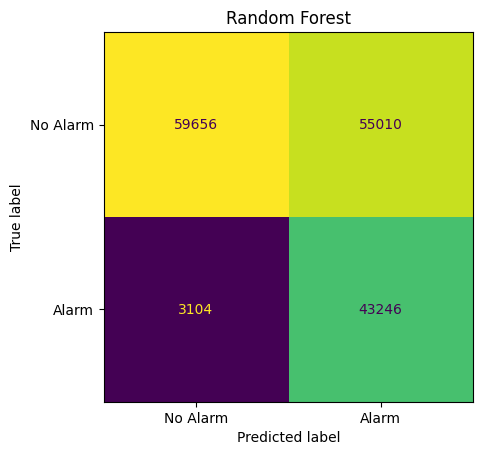

In [6]:
cm = confusion_matrix(y_test, y_pred_03) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Random Forest')
plt.show()

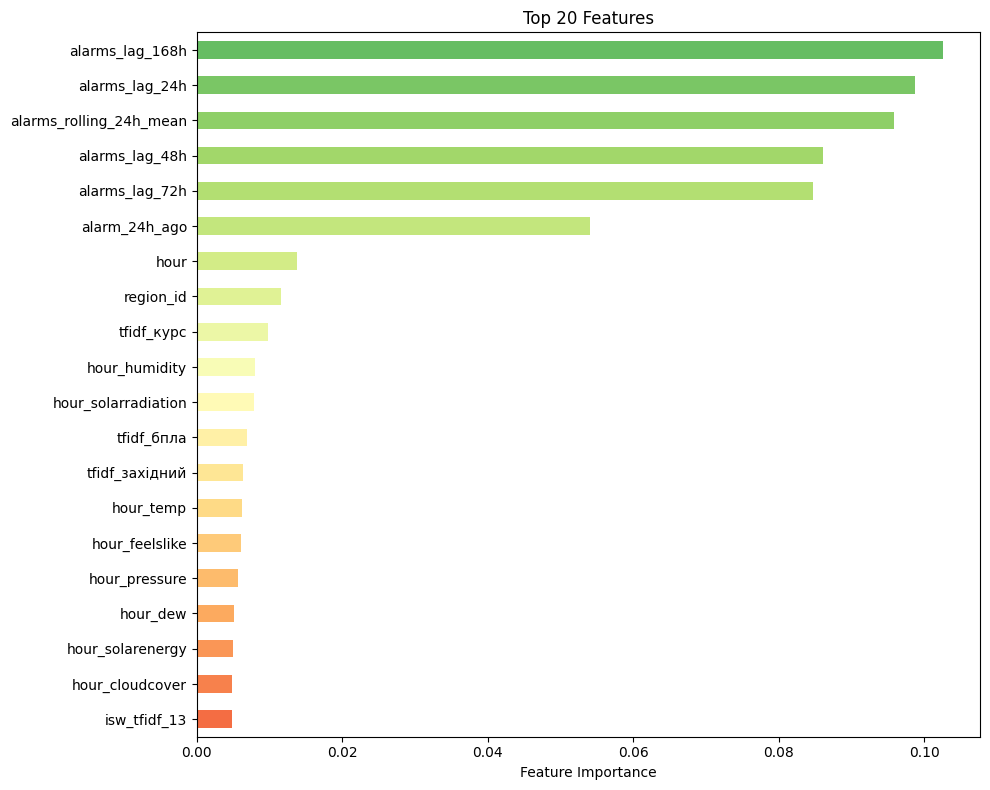

In [8]:
feat_imp = pd.Series(model_rf.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
with open('6__random_forest__v1.pkl', 'wb') as f:
    pickle.dump(model, f)